# Diffusion Model per Segmentazione Vasi Sanguigni
In questo notebook costruiremo un Modello di Diffusione (Denoising Diffusion Probabilistic Model) da zero per la segmentazione dei vasi sanguigni in immagini del fundus oculare.
A differenza della generazione incondizionata, qui useremo una **generazione condizionata**: il modello imparerà a generare la maschera corretta dei vasi sanguigni basandosi sull'immagine dell'occhio.


**Sources:**
- [YouTube video](https://www.youtube.com/watch?v=a4Yfz2FxXiY).

- [Colab originale](https://colab.research.google.com/drive/1sjy9odlSSy0RBVgMTgP7s99NXsqglsUL?usp=sharing)
- Github implementation [Denoising Diffusion Pytorch](https://github.com/lucidrains/denoising-diffusion-pytorch)
- Niels Rogge, Kashif Rasul, [Huggingface notebook](https://colab.research.google.com/github/huggingface/notebooks/blob/main/examples/annotated_diffusion.ipynb#scrollTo=3a159023)
- Papers on Diffusion models ([Dhariwal, Nichol, 2021], [Ho et al., 2020] ect.)
For a great introduction to UNets, have a look at this post: https://amaarora.github.io/posts/2020-09-13-unet.html

#Dataset

In [1]:
from google.colab import drive
import os
import datetime
from zoneinfo import ZoneInfo

drive.mount('/content/drive')
BASE_DIR=f'/content/drive/MyDrive/Advanced_Machine_Learning/diffusion_output/'

 #Se si vuole far partire la rete da zero mettere True
new=False
if new:
  run_timestamp = datetime.datetime.now(tz=ZoneInfo('Europe/Rome')).strftime("%Y%m%d_%H%M")
  PROJECT_DIR =os.path.join(BASE_DIR,run_timestamp)
  # Crea la cartella automaticamente se non esiste già
  os.makedirs(PROJECT_DIR, exist_ok=True)
  print(f"Cartella di progetto pronta in: {PROJECT_DIR}")
else:# In caso di resume training
  RESUME_DIR= os.path.join(BASE_DIR,"20260521_0100")
  percorso_checkpoint = os.path.join(RESUME_DIR, "checkpoint_epoch_110.pth")
  if os.path.isfile(percorso_checkpoint):
    print("File correctly found")


Mounted at /content/drive
File correctly found


In [2]:
# ==========================================
# METRICHE CUSTOM DI VALUTAZIONE
# ==========================================
import math
import torch
import torch.nn.functional as F

# Poiché il nostro modello di diffusione lavora con immagini normalizzate tra [-1, 1],
# lo 0.0 è il nostro "spartiacque" perfetto tra sfondo (negativo) e vaso sanguigno (positivo).
MASK_THRESHOLD = 0.0

def dice_score(
    predictions: torch.Tensor,
    targets: torch.Tensor,
    threshold: float = MASK_THRESHOLD,
    smooth: float = 1.0,
    from_logits: bool = False,
    ) -> float:
    with torch.no_grad():
        if from_logits:
            predictions = torch.sigmoid(predictions)
        pred_binary = (predictions > threshold).float()
        targets_flat = targets.view(targets.shape[0], -1).float()
        pred_flat    = pred_binary.view(pred_binary.shape[0], -1)
        intersection = (pred_flat * targets_flat).sum(dim=1)
        dice = (2.0 * intersection + smooth) / (pred_flat.sum(dim=1) + targets_flat.sum(dim=1) + smooth)
        return dice.mean().item()

def iou_score(
    predictions: torch.Tensor,
    targets: torch.Tensor,
    threshold: float = MASK_THRESHOLD,
    smooth: float = 1.0,
    from_logits: bool = False,
    ) -> float:
    with torch.no_grad():
        if from_logits:
            predictions = torch.sigmoid(predictions)
        pred_binary  = (predictions > threshold).float()
        targets_flat = targets.view(targets.shape[0], -1).float()
        pred_flat    = pred_binary.view(pred_binary.shape[0], -1)
        intersection = (pred_flat * targets_flat).sum(dim=1)
        union        = pred_flat.sum(dim=1) + targets_flat.sum(dim=1) - intersection
        iou          = (intersection + smooth) / (union + smooth)
        return iou.mean().item()

def pixel_accuracy(
    predictions: torch.Tensor,
    targets: torch.Tensor,
    threshold: float = MASK_THRESHOLD,
    from_logits: bool = False,
    ) -> float:
    with torch.no_grad():
        if from_logits:
            predictions = torch.sigmoid(predictions)
        pred_binary = (predictions > threshold).float()
        correct     = (pred_binary == targets).float()
        return correct.mean().item()

def get_boundary(
    mask: torch.Tensor,
    ) -> torch.Tensor:
    eroded = 1 - F.max_pool2d(1 - mask, kernel_size=3, stride=1, padding=1)
    return mask - eroded

def average_hausdorff_distance(
    predictions: torch.Tensor,
    targets: torch.Tensor,
    threshold: float = MASK_THRESHOLD,
    from_logits: bool = False,
    ) -> float:
    with torch.no_grad():
        if from_logits:
            predictions = torch.sigmoid(predictions)

        pred_bin = (predictions > threshold).float()
        tgt_bin = targets.float()

        bound_pred = get_boundary(pred_bin)
        bound_tgt = get_boundary(tgt_bin)

        B, _, H, W = pred_bin.shape
        max_dist = math.sqrt(H**2 + W**2)

        ahd_batch = []
        for i in range(B):
            pts_p = torch.nonzero(bound_pred[i, 0]).float()
            pts_t = torch.nonzero(bound_tgt[i, 0]).float()

            if len(pts_p) == 0 and len(pts_t) == 0:
                ahd_batch.append(0.0)
            elif len(pts_p) == 0 or len(pts_t) == 0:
                ahd_batch.append(max_dist)
            else:
                dists = torch.cdist(pts_p, pts_t)
                d_p_t = dists.min(dim=1)[0].mean()
                d_t_p = dists.min(dim=0)[0].mean()
                ahd_batch.append(max(d_p_t, d_t_p).item())

        return sum(ahd_batch) / len(ahd_batch)


## 1. Investigazione del Dataset
Il dataset comprende 600 immagini di train (2048x2048) e 200 di test, corredate da maschere in bianco e nero.
Procediamo con il download tramite `kagglehub` e visualizziamo una coppia (immagine + maschera) per analizzare i nostri dati.

In [3]:
# @title
import kagglehub
import os
import glob
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path # Import Path

# 1. Download del dataset
print("Download del dataset in corso...")
path = Path(kagglehub.dataset_download("nikitamanaenkov/fundus-image-dataset-for-vessel-segmentation")) # Convert path to Path object
print("Path ai file del dataset:", path)
train_img_dir  =path / "train" / "Original"
train_mask_dir =path / "train" / "Ground truth"
test_img_dir   =path / "test"  / "Original"
test_mask_dir  =path / "test"  / "Ground truth"

Download del dataset in corso...
Using Colab cache for faster access to the 'fundus-image-dataset-for-vessel-segmentation' dataset.
Path ai file del dataset: /kaggle/input/fundus-image-dataset-for-vessel-segmentation



Esplorazione delle cartelle scaricate:
- /kaggle/input/fundus-image-dataset-for-vessel-segmentation (contiene 1 file)
- /kaggle/input/fundus-image-dataset-for-vessel-segmentation/test/Ground truth (contiene 200 file)
- /kaggle/input/fundus-image-dataset-for-vessel-segmentation/test/Original (contiene 200 file)
- /kaggle/input/fundus-image-dataset-for-vessel-segmentation/train/Ground truth (contiene 600 file)
- /kaggle/input/fundus-image-dataset-for-vessel-segmentation/train/Original (contiene 601 file)

Trovate 600 immagini originali e 600 maschere.


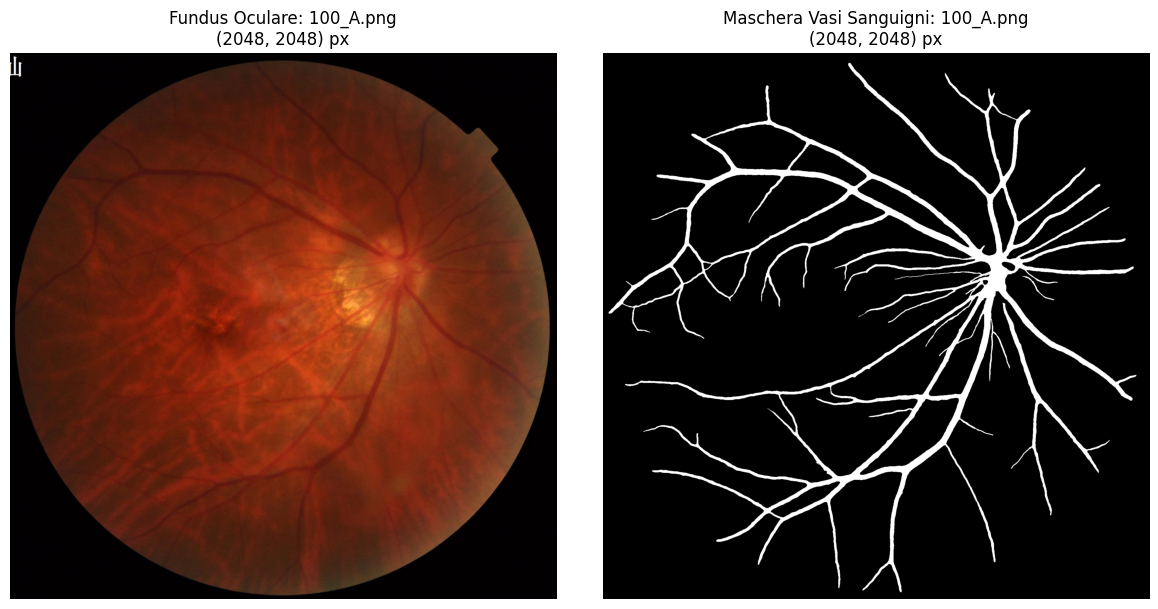

In [4]:
# @title
# 2. Esplorazione della struttura delle directory
print("\nEsplorazione delle cartelle scaricate:")
for root, dirs, files in os.walk(path):
    if len(files) > 0:
        print(f"- {root} (contiene {len(files)} file)")

# 3. Raccolta dei percorsi delle immagini e delle maschere
# Raccogliamo tutte le immagini presenti nel dataset scaricato
all_images = glob.glob(os.path.join(path, '**', '*.*'), recursive=True)
all_images = [f for f in all_images if f.endswith(('.png', '.jpg', '.jpeg', '.tif'))]

# Cerchiamo di separare le immagini originali dalle maschere in base ai nomi delle cartelle o dei file
# (La logica di filtro potrebbe variare leggermente in base a come l'autore ha nominato i file su Kaggle)
mask_images = [f for f in train_mask_dir.glob('*.*') if f.suffix.lower() in ['.png', '.jpg', '.jpeg', '.tif']]
original_images = [f for f in train_img_dir.glob('*.*') if f.suffix.lower() in ['.png', '.jpg', '.jpeg', '.tif']]

# Ordiniamole in modo che gli indici combacino (se i nomi file sono coerenti)
original_images.sort()
mask_images.sort()

print(f"\nTrovate {len(original_images)} immagini originali e {len(mask_images)} maschere.")

# 4. Visualizzazione di un esempio
if len(original_images) > 0 and len(mask_images) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Visualizza Immagine Originale
    img = Image.open(original_images[0])
    axes[0].imshow(img)
    axes[0].set_title(f"Fundus Oculare: {original_images[0].name}\n{img.size} px")
    axes[0].axis('off')

    # Visualizza Maschera
    mask = Image.open(mask_images[0])
    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title(f"Maschera Vasi Sanguigni: {mask_images[0].name}\n{mask.size} px")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Non è stato possibile separare automaticamente immagini e maschere. Verifica la struttura dei file stampata sopra.")

## 2. Creazione del Dataset e del DataLoader
Dobbiamo creare una classe PyTorch personalizzata che carichi le coppie di immagini (Fundus + Maschera).
Entrambe le immagini verranno:
1. Ridimensionate a 256x256 pixel.
2. Convertite in tensori di PyTorch.
3. Normalizzate nell'intervallo [-1, 1], che è lo standard per le reti neurali nei modelli di diffusione.

L'immagine del fundus avrà 3 canali (RGB), mentre la maschera dei vasi sanguigni avrà 1 solo canale (Grayscale).

Dataset creato! Numero di immagini pronte per il train: 600
Shape del batch di immagini (Fundus): torch.Size([8, 3, 256, 256]) --> (Batch, Channels, Height, Width)
Shape del batch di maschere (Vasi):  torch.Size([8, 1, 256, 256]) --> (Batch, Channels, Height, Width)
Range Immagini: [-1.00, 1.00]
Range Maschere: [-1.00, 1.00]


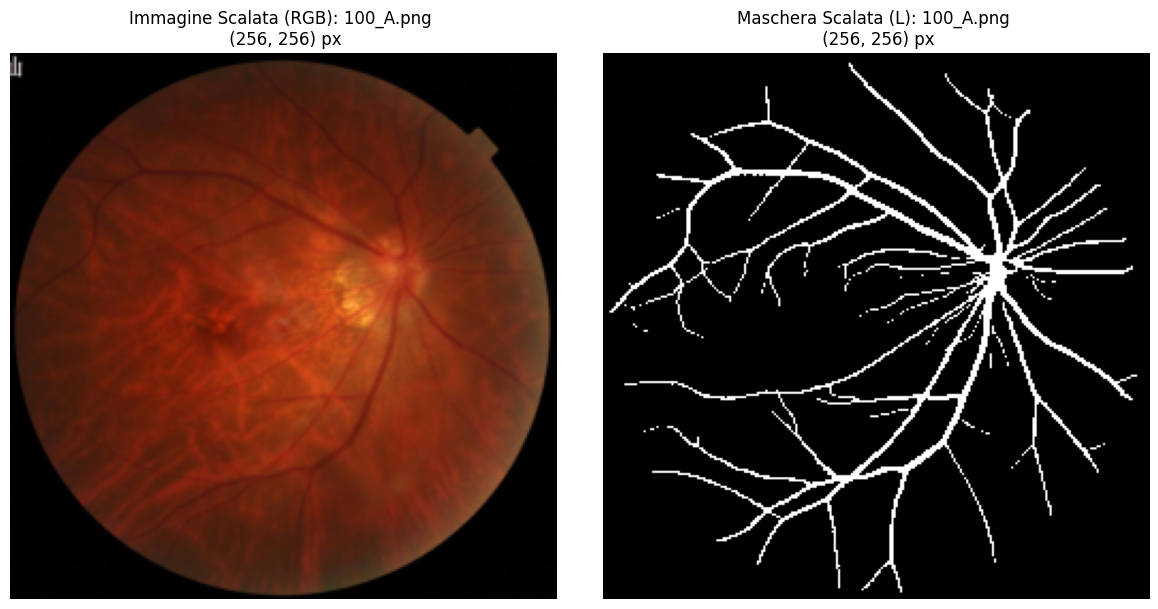

In [5]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.transforms.functional as F
import matplotlib.pyplot as plt

class FundusDataset(Dataset):
    def __init__(self, image_paths, mask_paths, img_size=256):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.img_size = img_size

        # Trasformazione per l'immagine del Fundus (RGB)
        self.transform_img = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) # Normalizza RGB in [-1, 1]
        ])

        # Trasformazione per la Maschera (Grayscale)
        self.transform_mask = transforms.Compose([
            transforms.Resize((img_size, img_size), interpolation=transforms.InterpolationMode.NEAREST),
            transforms.Grayscale(num_output_channels=1),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5]) # Normalizza Grayscale in [-1, 1]
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        mask_path = self.mask_paths[idx]

        # Carichiamo le immagini assicurandoci che il formato sia corretto
        img = Image.open(img_path).convert('RGB')
        mask = Image.open(mask_path).convert('L') # 'L' sta per luma (scala di grigi)

        img_tensor = self.transform_img(img)
        mask_tensor = self.transform_mask(mask)

        return img_tensor, mask_tensor

# Parametri
IMG_SIZE = 256  # Risoluzione per la U-Net
BATCH_SIZE = 8  # Riduci a 4 se ottieni un errore "CUDA out of memory"

# Utilizziamo le liste generate nella cella di investigazione
train_dataset = FundusDataset(original_images, mask_images, img_size=IMG_SIZE)

# Drop_last=True evita crash se l'ultimo batch è più piccolo del BATCH_SIZE impostato
dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

print(f"Dataset creato! Numero di immagini pronte per il train: {len(train_dataset)}")

# Estraiamo un batch per verificare le dimensioni dei tensori
img_batch, mask_batch = next(iter(dataloader))
print(f"Shape del batch di immagini (Fundus): {img_batch.shape} --> (Batch, Channels, Height, Width)")
print(f"Shape del batch di maschere (Vasi):  {mask_batch.shape} --> (Batch, Channels, Height, Width)")

# Verifichiamo i range per accertarci della normalizzazione
print(f"Range Immagini: [{img_batch.min():.2f}, {img_batch.max():.2f}]")
print(f"Range Maschere: [{mask_batch.min():.2f}, {mask_batch.max():.2f}]")

# Visualizzazione della prima immagine processata
img_sample, mask_sample = train_dataset[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Denormalizzazione per visualizzazione
img_show = (img_sample.permute(1, 2, 0).numpy() * 0.5) + 0.5
mask_show = (mask_sample.squeeze().numpy() * 0.5) + 0.5

axes[0].imshow(img_show)
axes[0].set_title(f"Immagine Scalata (RGB): {original_images[0].name} \n ({IMG_SIZE}, {IMG_SIZE}) px")
axes[0].axis('off')

axes[1].imshow(mask_show, cmap='gray')
axes[1].set_title(f"Maschera Scalata (L): {mask_images[0].name} \n ({IMG_SIZE}, {IMG_SIZE}) px")
axes[1].axis('off')

plt.tight_layout()
plt.show()

###Come viene effettuato il resizing
Nel codice che abbiamo usato, l'immagine non viene tagliata (non prendiamo un pezzo casuale), ma viene "compressa" (o scalata). L'intera immagine originale di 2048x2048 pixel viene "schiacciata" per entrare in una griglia di 256x256 pixel.

Se avessimo voluto prendere un pezzo casuale dell'immagine avremmo usato una tecnica chiamata Cropping (in PyTorch si usa transforms.RandomCrop), che si usa spesso per non perdere i dettagli dei vasi più piccoli, ma richiede un approccio di ricostruzione finale dell'immagine un po' più complesso.

Visto che stiamo "schiacciando" l'immagine, il computer deve calcolare di che colore sarà ogni singolo pixel della nuova immagine più piccola. Per farlo, utilizza degli algoritmi matematici chiamati Metodi di Interpolazione.

Nel nostro codice abbiamo usato due metodi diversi di proposito: uno per l'immagine dell'occhio e uno per la maschera. Ecco come funzionano:

###1. Per l'immagine del Fundus (RGB): Interpolazione Bilineare (Bilinear)
Nel codice abbiamo scritto semplicemente transforms.Resize((img_size, img_size)). Quando non specifichiamo nulla, PyTorch usa di default l'Interpolazione Bilineare.

Come funziona: Quando deve creare un nuovo pixel, l'algoritmo guarda i 4 pixel più vicini nell'immagine originale e ne fa una media ponderata.

Il risultato: Crea un'immagine morbida e sfumata. È perfetto per le fotografie (come l'immagine del nostro occhio), perché i passaggi di colore e luce rimangono naturali, senza creare un fastidioso effetto "a quadrettoni" (pixelato).

###2. Per la Maschera (Bianco e Nero): Nearest Neighbor (Vicino più prossimo)
Nel codice per la maschera abbiamo specificato: interpolation=transforms.InterpolationMode.NEAREST.

Come funziona: Questo algoritmo non fa nessuna media. Quando deve creare un nuovo pixel, guarda semplicemente qual è il singolo pixel più vicino nell'immagine originale e ne copia il valore esatto.

**Il risultato**: Non crea sfumature. I contorni rimangono netti (o "seghettati").

Perché è vitale per le maschere? Nelle nostre maschere, i pixel hanno un significato preciso: bianco (valore 1) significa "c'è un vaso sanguigno", nero (valore 0) significa "sfondo". Se usassimo l'interpolazione bilineare qui, i bordi dei vasi diventerebbero grigi (es. valore 0.5), confondendo il modello (che si chiederebbe: "questo grigio è mezzo vaso sanguigno o cosa?"). Usando il Nearest Neighbor, ci assicuriamo che la maschera ridimensionata rimanga strettamente bianca o nera.

# Building the Diffusion Model


## Step 1: Forward Diffusion Process = Noise scheduler
In questa fase definiamo la "Noise Schedule" (come il rumore viene aggiunto nel tempo) e la funzione che corrompe i dati.
Poiché stiamo creando un modello condizionato per la segmentazione, la funzione `q_sample` (che aggiunge il rumore) verrà applicata **esclusivamente alla maschera dei vasi sanguigni** (`x_0`). L'immagine originale del fundus rimarrà inalterata per fare da guida al modello.

Stiamo facendo una generazione condizionata (segmentazione). L'obiettivo del nostro modello sarà guardare l'immagine dell'occhio e predire la maschera dei vasi sanguigni.
Per fargli imparare questo compito, durante il training noi:

1. Lasciamo l'immagine del fundus (l'occhio) perfettamente intatta (ci servirà come "suggerimento" o condizione).

2. Aggiungiamo rumore solo alla maschera dei vasi sanguigni, in modo graduale.

Il modello riceverà in input l'occhio intatto e la maschera rovinata dal rumore, e dovrà indovinare quale rumore è stato aggiunto alla maschera per poterlo sottrarre e "pulirla".

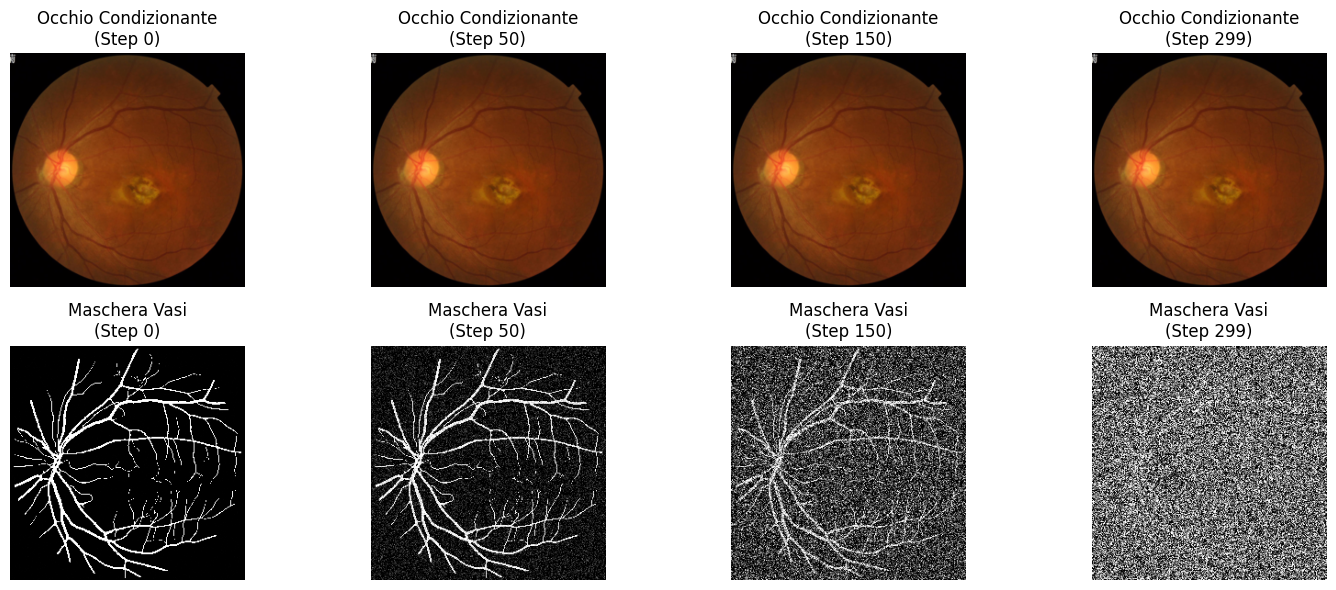

In [6]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# 1. Definiamo la Schedulazione del Rumore (Linear Beta Schedule)
def linear_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    return torch.linspace(beta_start, beta_end, timesteps)

TIMESTEPS = 300 # Numero di passi di diffusione (300 è un buon compromesso per Colab, di solito è 1000)

# Calcoliamo tutte le costanti che ci serviranno per le formule matematiche del forward process
# cumprod = prodotto cumulativo
betas = linear_beta_schedule(timesteps=TIMESTEPS)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, axis=0)

# Costanti per il forward process q(x_t | x_0)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)

def extract(a, t, x_shape):
    """
    Estrae i coefficienti corretti per il batch corrente in base al timestep t.
    Modella la forma del tensore per permettere il broadcasting con le immagini.
    """
    batch_size = t.shape[0]
    out = a.gather(-1, t.cpu())
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)

# 2. La funzione Forward
def q_sample(x_start, t, noise=None):
    """
    Applica il rumore al timestep 't'. Nel nostro caso x_start sarà LA MASCHERA.
    Formula: x_t = sqrt(alpha_bar_t) * x_start + sqrt(1 - alpha_bar_t) * noise
    """
    if noise is None:
        noise = torch.randn_like(x_start) # Rumore gaussiano puro

    sqrt_alphas_cumprod_t = extract(sqrt_alphas_cumprod, t, x_start.shape)
    sqrt_one_minus_alphas_cumprod_t = extract(sqrt_one_minus_alphas_cumprod, t, x_start.shape)

    return sqrt_alphas_cumprod_t * x_start + sqrt_one_minus_alphas_cumprod_t * noise

# 3. Visualizziamo l'effetto del Forward Process
# Creiamo una funzione per riportare i tensori da [-1, 1] a [0, 1] per visualizzarli
def unnormalize_to_show(tensor):
    img = (tensor + 1) / 2
    img = img.clamp(0, 1)
    # Spostiamo i canali alla fine per matplotlib (C, H, W) -> (H, W, C)
    return img.permute(1, 2, 0).cpu().numpy()

# Prendiamo un'immagine e una maschera dal batch dello Step 2
img_esempio = img_batch[0:1]    # Shape [1, 3, 256, 256]
maschera_esempio = mask_batch[0:1]  # Shape [1, 1, 256, 256]

# Scegliamo alcuni step temporali per vedere il degrado
steps_da_mostrare = [0, 50, 150, 299]

fig, axes = plt.subplots(2, len(steps_da_mostrare), figsize=(15, 6))

for i, t_val in enumerate(steps_da_mostrare):
    # Creiamo un tensore per il timestep
    t = torch.tensor([t_val])

    # Aggiungiamo il rumore SOLO ALLA MASCHERA
    maschera_rumorosa = q_sample(maschera_esempio, t)

    # Riga 1: L'immagine condizionante (l'occhio), che resta SEMPRE UGUALE
    ax_img = axes[0, i]
    ax_img.imshow(unnormalize_to_show(img_esempio[0]))
    ax_img.set_title(f"Occhio Condizionante\n(Step {t_val})")
    ax_img.axis('off')

    # Riga 2: La maschera che diventa progressivamente rumore
    ax_mask = axes[1, i]
    # Essendo scala di grigi (1 canale), rimuoviamo l'ultima dimensione per plt.imshow
    ax_mask.imshow(unnormalize_to_show(maschera_rumorosa[0]).squeeze(-1), cmap='gray')
    ax_mask.set_title(f"Maschera Vasi\n(Step {t_val})")
    ax_mask.axis('off')

plt.tight_layout()
plt.show()


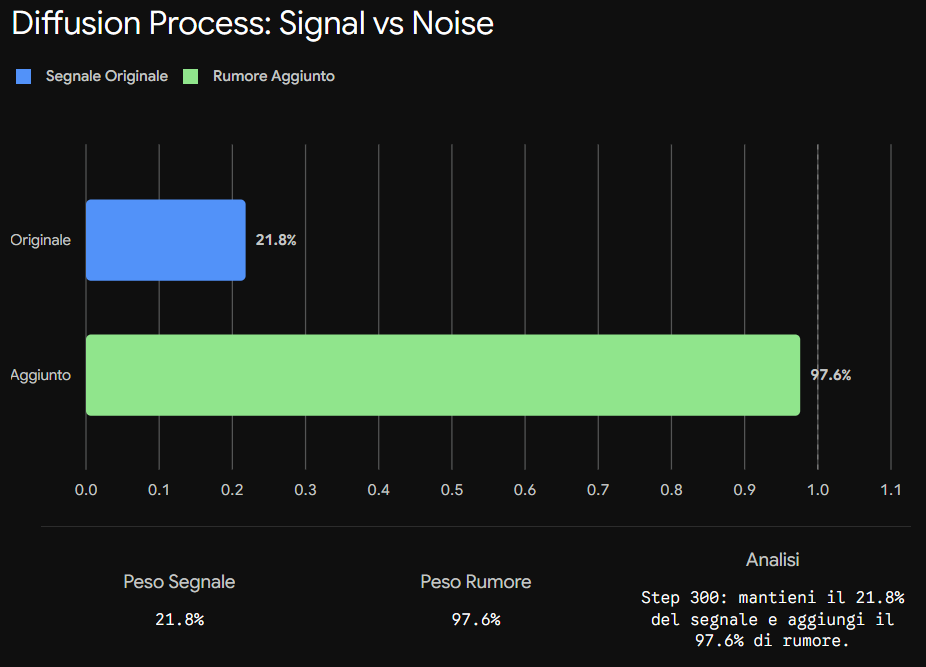

## Step 2: The backward process = Architettura U-Net Condizionata
Costruiamo una U-Net semplificata. Le differenze principali rispetto a una U-Net tradizionale sono due:
1. **Time Embeddings:** La rete deve sapere a che "step temporale (t)" si trova l'immagine per capire quanto rumore c'è. Usiamo degli embedding sinusoidali (come nei Transformer) per iniettare l'informazione del tempo in ogni blocco.
2. **Canali di Input/Output:** In ingresso concateniamo l'immagine del fundus (3 canali) e la maschera rumorosa (1 canale), per un totale di 4 canali. In uscita avremo 1 canale (il rumore predetto).

In [7]:
import torch
import torch.nn as nn
import math

# 1. Time Embeddings (come in Attention Is All You Need)
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

# 2. Blocco Base della U-Net
class Block(nn.Module):
    def __init__(self, in_c, out_c, time_emb_dim, up=False):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_c)
        if up:
            self.conv1 = nn.Conv2d(2 * in_c, out_c, 3, padding=1)
            self.transform = nn.ConvTranspose2d(out_c, out_c, 4, 2, 1)
        else:
            self.conv1 = nn.Conv2d(in_c, out_c, 3, padding=1)
            self.transform = nn.Conv2d(out_c, out_c, 4, 2, 1)

        self.conv2 = nn.Conv2d(out_c, out_c, 3, padding=1)
        self.bnorm1 = nn.BatchNorm2d(out_c)
        self.bnorm2 = nn.BatchNorm2d(out_c)
        self.relu  = nn.ReLU()

    def forward(self, x, t):
        # Prima convoluzione
        h = self.bnorm1(self.relu(self.conv1(x)))
        # Iniettiamo il tempo: lo proiettiamo, aggiungiamo le dimensioni spaziali e lo sommiamo
        time_emb = self.relu(self.time_mlp(t))
        time_emb = time_emb[(..., ) + (None, ) * 2]
        h = h + time_emb
        # Seconda convoluzione
        h = self.bnorm2(self.relu(self.conv2(h)))
        # Upsample o Downsample
        return self.transform(h)

# 3. La U-Net Condizionata Completa
class ConditionalUNet(nn.Module):
    def __init__(self):
        super().__init__()
        image_channels = 3 # Immagine fundus
        mask_channels = 1  # Maschera rumorosa
        in_channels = image_channels + mask_channels # 4 canali in totale
        out_channels = 1 # Rumore predetto

        down_channels = (64, 128, 256)
        up_channels = (256, 128, 64)
        time_emb_dim = 32

        # Rete per processare il tempo
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU()
        )

        # Convoluzione iniziale
        self.conv0 = nn.Conv2d(in_channels, down_channels[0], 3, padding=1)

        # Downsample (Encoder)
        self.downs = nn.ModuleList([
            Block(down_channels[0], down_channels[1], time_emb_dim),
            Block(down_channels[1], down_channels[2], time_emb_dim),
        ])

        # Upsample (Decoder)
        self.ups = nn.ModuleList([
            Block(up_channels[0], up_channels[1], time_emb_dim, up=True),
            Block(up_channels[1], up_channels[2], time_emb_dim, up=True),
        ])

        # Output
        self.output = nn.Conv2d(up_channels[-1], out_channels, 1)

    def forward(self, x, cond, timestep):
        # 1. Calcoliamo l'embedding del tempo
        t = self.time_mlp(timestep)

        # 2. CONCATENIAMO condizionamento (occhio) e input (maschera rumorosa) lungo i canali
        x = torch.cat([cond, x], dim=1) # da [B, 3, H, W] e [B, 1, H, W] -> [B, 4, H, W]

        # 3. Passiamo attraverso la rete
        x = self.conv0(x)

        residual_inputs = []
        for down in self.downs:
            x = down(x, t)
            residual_inputs.append(x) # Salviamo per le skip connections

        for up in self.ups:
            residual_x = residual_inputs.pop()
            # Skip connection: concateniamo
            x = torch.cat((x, residual_x), dim=1)
            x = up(x, t)

        return self.output(x)

# 4. Testiamo il modello per assicurarci che le dimensioni combacino
model = ConditionalUNet()
print(f"Modello creato con successo! Parametri totali: {sum(p.numel() for p in model.parameters()):,}")

# Usiamo i batch estratti negli step precedenti come test
# img_batch (l'occhio): [8, 3, 256, 256]
# mask_batch (la maschera che fingiamo sia rumorosa): [8, 1, 256, 256]
# t (timestep casuali per le 8 immagini): [8]
t_random = torch.randint(0, TIMESTEPS, (BATCH_SIZE,))

# Passiamo tutto nella U-Net
rumore_predetto = model(mask_batch, img_batch, t_random)

print(f"Shape dell'immagine di input (Occhio): {img_batch.shape}")
print(f"Shape della maschera di input: {mask_batch.shape}")
print(f"Shape del tempo: {t_random.shape}")
print(f"Shape dell'output (Rumore Predetto): {rumore_predetto.shape} -> Deve essere [Batch, 1, Height, Width]")

Modello creato con successo! Parametri totali: 3,692,449
Shape dell'immagine di input (Occhio): torch.Size([8, 3, 256, 256])
Shape della maschera di input: torch.Size([8, 1, 256, 256])
Shape del tempo: torch.Size([8])
Shape dell'output (Rumore Predetto): torch.Size([8, 1, 256, 256]) -> Deve essere [Batch, 1, Height, Width]


## Step 3: Training Loop
Inizializziamo l'ottimizzatore (Adam) e impostiamo la funzione di costo (Mean Squared Error - MSE).
L'MSE misurerà la differenza tra il rumore reale che abbiamo aggiunto alla maschera e il rumore predetto dalla rete.
Mettiamo il modello sulla GPU (se disponibile) per velocizzare i calcoli.
Per testare che tutto funzioni senza errori, imposteremo un numero basso di epoche (es. 5). Per ottenere risultati reali di segmentazione, questo numero andrà alzato (es. 100-300).

### TRAINING DA ZERO

In [ ]:
import torch.optim as optim
import time

# 1. Configurazione del Device (GPU o CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Sto usando il device: {device}")

# Spostiamo il modello sulla GPU
model.to(device)

# 2. Impostazioni di Training
EPOCHS = 150
LEARNING_RATE = 1e-4
SAVE_EVERY_N_EPOCHS = 10  # Salva un file ogni 10 epoche

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Funzione per calcolare il tempo trascorso
def format_time(seconds):
    mins = int(seconds // 60)
    secs = int(seconds % 60)
    return f"{mins}m {secs}s"

print("Inizio Addestramento...")

# 3. Il Loop di Addestramento
for epoch in range(EPOCHS):
    model.train() # Mettiamo il modello in modalità training
    epoch_loss = 0.0
    start_time = time.time()

    for step, (img, mask) in enumerate(dataloader):
        # Spostiamo i dati sulla GPU
        img = img.to(device)
        mask = mask.to(device)

        # Azzeriamo i gradienti dello step precedente
        optimizer.zero_grad()

        batch_size = img.shape[0]

        # A) Scegliamo un timestep 't' casuale per ogni immagine nel batch
        # t sarà un numero tra 0 e TIMESTEPS-1
        t = torch.randint(0, TIMESTEPS, (batch_size,), device=device).long()

        # B) Generiamo il vero rumore gaussiano che vogliamo aggiungere alla maschera
        true_noise = torch.randn_like(mask).to(device)

        # C) Aggiungiamo il rumore alla maschera (Forward Process)
        # q_sample farà la matematica per noi usando le costanti calcolate in precedenza
        noisy_mask = q_sample(mask, t, noise=true_noise)

        # D) Chiediamo alla U-Net di predire il rumore
        # Ricorda: passiamo la maschera rumorosa, l'immagine condizionante (occhio) e il tempo t
        predicted_noise = model(noisy_mask, img, t)

        # E) Calcoliamo l'errore (MSE Loss) tra il rumore predetto e quello vero
        loss = F.mse_loss(predicted_noise, true_noise)

        # F) Backpropagation e aggiornamento dei pesi
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        # Stampiamo l'avanzamento ogni 10 step per non inondare la console
        if (step + 1) % 10 == 0:
            print(f"  [Epoch {epoch+1}/{EPOCHS} - Step {step+1}/{len(dataloader)}] Loss corrente: {loss.item():.4f}")

    # Fine Epoca: stampiamo un riassunto
    avg_epoch_loss = epoch_loss / len(dataloader)
    end_time = time.time()
    print(f"=== Fine Epoch {epoch+1}/{EPOCHS} | Loss Media: {avg_epoch_loss:.4f} | Tempo: {format_time(end_time - start_time)} ===")

    ### NUOVO: Salvataggio Checkpoint Completo su Drive ###
    if (epoch + 1) % SAVE_EVERY_N_EPOCHS == 0:
        checkpoint_path = os.path.join(PROJECT_DIR, f"checkpoint_epoch_{epoch+1}.pth")

        # Creiamo un dizionario con tutto ciò che ci serve ricordare
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_epoch_loss
        }

        torch.save(checkpoint, checkpoint_path)
        print(f"📁 Checkpoint completo salvato su Drive: {checkpoint_path}")

print("Addestramento completato.")

Sto usando il device: cuda
Inizio Addestramento...
  [Epoch 1/150 - Step 10/75] Loss corrente: 0.5807
  [Epoch 1/150 - Step 20/75] Loss corrente: 0.3553
  [Epoch 1/150 - Step 30/75] Loss corrente: 0.3062
  [Epoch 1/150 - Step 40/75] Loss corrente: 0.2003
  [Epoch 1/150 - Step 50/75] Loss corrente: 0.2720
  [Epoch 1/150 - Step 60/75] Loss corrente: 0.2054
  [Epoch 1/150 - Step 70/75] Loss corrente: 0.2493
=== Fine Epoch 1/150 | Loss Media: 0.3399 | Tempo: 3m 9s ===
  [Epoch 2/150 - Step 10/75] Loss corrente: 0.1534
  [Epoch 2/150 - Step 20/75] Loss corrente: 0.1063
  [Epoch 2/150 - Step 30/75] Loss corrente: 0.1242
  [Epoch 2/150 - Step 40/75] Loss corrente: 0.1610
  [Epoch 2/150 - Step 50/75] Loss corrente: 0.1697
  [Epoch 2/150 - Step 60/75] Loss corrente: 0.1593
  [Epoch 2/150 - Step 70/75] Loss corrente: 0.1717
=== Fine Epoch 2/150 | Loss Media: 0.1590 | Tempo: 2m 59s ===
  [Epoch 3/150 - Step 10/75] Loss corrente: 0.1696
  [Epoch 3/150 - Step 20/75] Loss corrente: 0.1062
  [Epoch 3

###RESUME TRAINING

In [8]:
import torch.optim as optim
import time

# 1. Ricreiamo il modello e l'ottimizzatore vuoti
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ConditionalUNet().to(device)
LEARNING_RATE = 1e-4
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# 3. Carichiamo il file
print(f"Caricamento del checkpoint da: {percorso_checkpoint}...")
checkpoint = torch.load(percorso_checkpoint, map_location=device)

# 4. Iniettiamo la "memoria" nel modello e nell'ottimizzatore
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoca_di_partenza = checkpoint['epoch']
loss_precedente = checkpoint['loss']

print(f"✅ Modello ripristinato! L'ultima volta si era fermato all'epoca {epoca_di_partenza} con una loss di {loss_precedente:.4f}")

# ==========================================
# RIPRESA DEL TRAINING LOOP
# ==========================================
EPOCHS_TOTALI = 150 # Il traguardo finale che vuoi raggiungere
print(epoca_di_partenza)

Caricamento del checkpoint da: /content/drive/MyDrive/Advanced_Machine_Learning/diffusion_output/20260521_0100/checkpoint_epoch_110.pth...
✅ Modello ripristinato! L'ultima volta si era fermato all'epoca 110 con una loss di 0.0180
110


In [9]:

if epoca_di_partenza >= EPOCHS_TOTALI:
    print(f"Traguardo di {EPOCHS_TOTALI} epoche già raggiunto")
    print("Salto l'addestramento e preparo il modello per il Sampling.")
else:
  print(f"Riprendo l'addestramento dall'epoca {epoca_di_partenza + 1} fino alla {EPOCHS_TOTALI}...")
  # Il ciclo for ora parte da 'epoca_di_partenza' invece che da zero
  for epoch in range(epoca_di_partenza, EPOCHS_TOTALI):
      model.train()
      epoch_loss = 0.0
      start_time = time.time()

      for step, (img, mask) in enumerate(dataloader):
          # Spostiamo i dati sulla GPU
          img = img.to(device)
          mask = mask.to(device)

          # Azzeriamo i gradienti dello step precedente
          optimizer.zero_grad()

          batch_size = img.shape[0]

          # A) Scegliamo un timestep 't' casuale per ogni immagine nel batch
          # t sarà un numero tra 0 e TIMESTEPS-1
          t = torch.randint(0, TIMESTEPS, (batch_size,), device=device).long()

          # B) Generiamo il vero rumore gaussiano che vogliamo aggiungere alla maschera
          true_noise = torch.randn_like(mask).to(device)

          # C) Aggiungiamo il rumore alla maschera (Forward Process)
          # q_sample farà la matematica per noi usando le costanti calcolate in precedenza
          noisy_mask = q_sample(mask, t, noise=true_noise)

          # D) Chiediamo alla U-Net di predire il rumore
          # Ricorda: passiamo la maschera rumorosa, l'immagine condizionante (occhio) e il tempo t
          predicted_noise = model(noisy_mask, img, t)

          # E) Calcoliamo l'errore (MSE Loss) tra il rumore predetto e quello vero
          loss = F.mse_loss(predicted_noise, true_noise)

          # F) Backpropagation e aggiornamento dei pesi
          loss.backward()
          optimizer.step()

          epoch_loss += loss.item()

          # Stampiamo l'avanzamento ogni 10 step per non inondare la console
          if (step + 1) % 10 == 0:
              print(f"  [Epoch {epoch+1}/{EPOCHS} - Step {step+1}/{len(dataloader)}] Loss corrente: {loss.item():.4f}")

      # Fine Epoca: stampiamo un riassunto
      avg_epoch_loss = epoch_loss / len(dataloader)
      end_time = time.time()
      print(f"=== Fine Epoch {epoch+1}/{EPOCHS} | Loss Media: {avg_epoch_loss:.4f} | Tempo: {format_time(end_time - start_time)} ===")

      ### NUOVO: Salvataggio Checkpoint Completo su Drive ###
      if (epoch + 1) % SAVE_EVERY_N_EPOCHS == 0:
          checkpoint_path = os.path.join(PROJECT_DIR, f"checkpoint_epoch_{epoch+1}.pth")

          # Creiamo un dizionario con tutto ciò che ci serve ricordare
          checkpoint = {
              'epoch': epoch + 1,
              'model_state_dict': model.state_dict(),
              'optimizer_state_dict': optimizer.state_dict(),
              'loss': avg_epoch_loss
          }

          torch.save(checkpoint, checkpoint_path)
          print(f"📁 Checkpoint completo salvato su Drive: {checkpoint_path}")

print("Addestramento completato.")

Riprendo l'addestramento dall'epoca 111 fino alla 150...


NameError: name 'EPOCHS' is not defined

## Sampling (Reverse Diffusion Process)
Fase di inferenza. Usiamo il decoratore `@torch.no_grad()` perché in questa fase non dobbiamo aggiornare i pesi (nessuna backpropagation), il che ci fa risparmiare moltissima RAM.
Definiamo la formula matematica per fare un singolo "passo indietro" nel tempo (`p_sample`) e poi creiamo il ciclo che ripete questa operazione da T=300 a T=0 (`p_sample_loop`). Infine, stampiamo il risultato.

In [ ]:
# Nuove costanti matematiche per il Reverse Process
# L'inverso della radice di alpha ci serve per "scalare" l'immagine al passo precedente
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

@torch.no_grad()
def p_sample(model, x, cond, t, t_index):
    """
    Esegue un singolo step di denoising (da t a t-1).
    x: la maschera rumorosa attuale
    cond: l'immagine originale dell'occhio (fundus)
    """
    # Estraiamo le costanti per questo specifico timestep
    betas_t = extract(betas, t, x.shape)
    sqrt_one_minus_alphas_cumprod_t = extract(sqrt_one_minus_alphas_cumprod, t, x.shape)
    sqrt_recip_alphas_t = extract(sqrt_recip_alphas, t, x.shape)

    # 1. Il modello predice il rumore presente in 'x'
    predicted_noise = model(x, cond, t)

    # 2. Formula matematica del DDPM per calcolare l'immagine al passo precedente
    # model_mean è la nostra "miglior ipotesi" della maschera più pulita
    model_mean = sqrt_recip_alphas_t * (x - betas_t * predicted_noise / sqrt_one_minus_alphas_cumprod_t)

    if t_index == 0:
        # Se siamo all'ultimo step (t=0), restituiamo l'immagine pulita
        return model_mean
    else:
        # Se non siamo a t=0, aggiungiamo una piccola dose di rumore (Langevin dynamics)
        # per evitare che l'immagine "collassi" e diventi troppo sfuocata.
        noise = torch.randn_like(x)
        return model_mean + torch.sqrt(betas_t) * noise

@torch.no_grad()
def p_sample_loop(model, cond_img):
    """
    Il ciclo iterativo che parte da rumore puro e arriva alla maschera finale.
    """
    device = cond_img.device
    b = cond_img.shape[0] # Batch size

    # Partiamo da rumore PURO (Shape: [Batch, 1, 256, 256])
    img = torch.randn((b, 1, IMG_SIZE, IMG_SIZE), device=device)

    # Salviamo i risultati intermedi per fare un bel grafico
    imgs_intermedie = []

    print("Generazione in corso... ci vorrà qualche secondo per fare 300 step!")

    # Ciclo al contrario: da 299 a 0
    for i in reversed(range(0, TIMESTEPS)):
        t = torch.full((b,), i, device=device, dtype=torch.long)
        img = p_sample(model, img, cond_img, t, i)

        # Salviamo la maschera ogni 50 step per vedere il progresso
        if i ==TIMESTEPS - 1 or i % 50 == 0:
            imgs_intermedie.append(img.cpu())

    return imgs_intermedie

# ==========================================
# ESECUZIONE DEL TEST
# ==========================================
model.eval() # Mettiamo il modello in modalità valutazione

# Prendiamo la prima immagine dell'occhio dal nostro batch (o potresti caricarne una dal Test Set)
# Shape: [1, 3, 256, 256]
occhio_di_test = img_batch[0:1].to(device)
maschera_reale = mask_batch[0:1] # La teniamo per confrontarla alla fine

# Eseguiamo il sampling
risultati_intermedi = p_sample_loop(model, occhio_di_test)

# Plotting dei risultati
fig, axes = plt.subplots(1, len(risultati_intermedi) + 2, figsize=(20, 5))

# 1. Mostriamo l'occhio (Input)
axes[0].imshow(unnormalize_to_show(occhio_di_test[0].cpu()))
axes[0].set_title("Input: Fundus")
axes[0].axis('off')

# 2. Mostriamo i passaggi intermedi del modello
step_titles = ["Step 299", "Step 250", "Step 200", "Step 150", "Step 100", "Step 50", "Finale (Step 0)"]
for i, img_intermedia in enumerate(risultati_intermedi):
    axes[i+1].imshow(unnormalize_to_show(img_intermedia[0]).squeeze(-1), cmap='gray')
    axes[i+1].set_title(step_titles[i])
    axes[i+1].axis('off')

# 3. Mostriamo la maschera reale (Ground Truth) per confronto
axes[-1].imshow(unnormalize_to_show(maschera_reale[0]).squeeze(-1), cmap='gray')
axes[-1].set_title("Target Reale")
axes[-1].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# ==========================================
# CALCOLO METRICHE SUL RISULTATO FINALE
# ==========================================

# 1. Recuperiamo l'immagine predetta finale (Step 0)
# risultati_intermedi è una lista. L'ultimo elemento [-1] è l'immagine a t=0.
img_finale = risultati_intermedi[-1].to(device)

# 2. Le tue metriche richiedono che il TARGET sia binario {0, 1}.
# Siccome maschera_reale è tra [-1, 1] (per via della normalizzazione iniziale),
# la binarizziamo al volo passando lo zero:
maschera_reale_binaria = (maschera_reale > 0.0).float().to(device)

# 3. Chiamiamo le tue funzioni!
# (Ricorda: from_logits=False perché i valori sono già in [-1, 1], non usiamo la sigmoide)
dice = dice_score(img_finale, maschera_reale_binaria, from_logits=False)
iou = iou_score(img_finale, maschera_reale_binaria, from_logits=False)
acc = pixel_accuracy(img_finale, maschera_reale_binaria, from_logits=False)
ahd = average_hausdorff_distance(img_finale, maschera_reale_binaria, from_logits=False)

print("\n" + "="*40)
print(" RISULTATI METRICHE CUSTOM")
print("="*40)
print(f"Dice Score (F1)     : {dice:.4f}")
print(f"IoU Score (Jaccard) : {iou:.4f}")
print(f"Pixel Accuracy      : {acc:.4f}")
print(f"Average Hausdorff   : {ahd:.4f} pixel")
print("="*40)